# Myelin Fibers Analysis

In this notebook, we will analyse the fibers in the cortex to analyze changes in architecture by assessing the distribution of radial and tangential fibers.

The pipeline will follow the following steps: 
1. Restrict the .tiff file to consider the cortex only 
2. Directional filtering: [directional_filtering.ijm](../fiji_macros/directional_filtering.ijm) which should be run directly in Fiji.
3. Separation between tangential and radial fibers
4. Statistical Analysis of the fibers

## 0. Preparation and Set-Up
In this first section, we will load the required librairies and the utils. 

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage import io
from skimage.draw import polygon
from skimage.filters import sato
from skimage.morphology import skeletonize, remove_small_objects
from skimage.feature import structure_tensor, structure_tensor_eigenvalues
from skimage.measure import label, regionprops
from roifile import ImagejRoi
from scipy.stats import mannwhitneyu, wilcoxon
import cv2
import imagej

from utils import *

%matplotlib inline

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

In [16]:
PROJECT_DIR = Path("..").resolve()

DATA_DIR = PROJECT_DIR / "data"
RAW_IMAGE_DIR = DATA_DIR / "tiff_files"
ROI_DIR = DATA_DIR / "roi_zip" 

RESULTS_DIR = PROJECT_DIR / "outputs" / "1_cortical_fibers"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

PREPROCESS_DIR = RESULTS_DIR / "preprocessed" 
PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
samples = match_images_to_rois(RAW_IMAGE_DIR, ROI_DIR)

samples

,sample_id,image_path,roi_zip_path
0,demo_image,/Users/lauraducret/blackgold-myelin-pipeline/d...,/Users/lauraducret/blackgold-myelin-pipeline/d...


## 1. Restriction to cortex

For the selected images, we will restrict the area to consider based on their ROIs on the cortex before processing. 

/Users/lauraducret/blackgold-myelin-pipeline/data/tiff_files/demo_image.tif
/Users/lauraducret/blackgold-myelin-pipeline/data/roi_zip/demo_image_RoiSet.zip
(5918, 7544) uint16 1742 65535


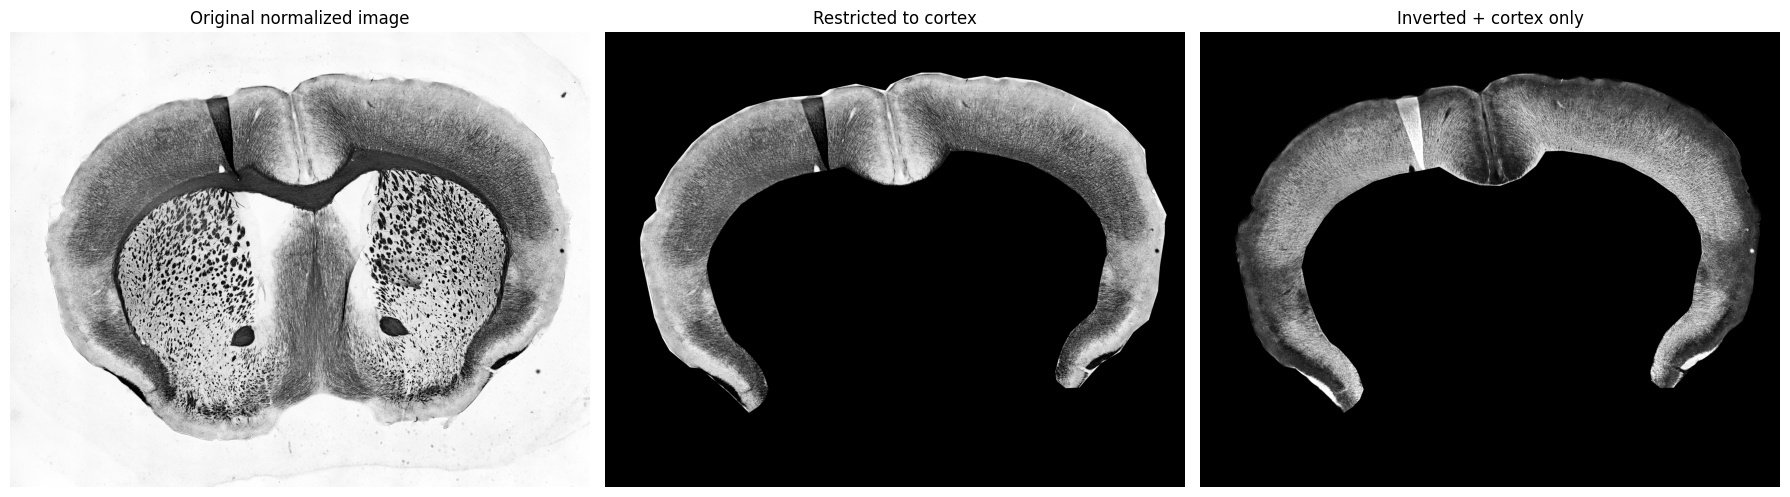

Saved: /Users/lauraducret/blackgold-myelin-pipeline/outputs/1_cortical_fibers/preprocessed/demo_image_cortex_inverted.tif


In [18]:
plot_intermediate = True

for _, sample in samples.iterrows():

    image_path = sample["image_path"]
    roi_path = sample["roi_zip_path"]

    print(image_path)
    print(roi_path)

    image = io.imread(image_path)

    if image.ndim == 3:
        image = image.mean(axis=2)

    print(image.shape, image.dtype, image.min(), image.max())

    image_norm = normalize01(image)

    rois = ImagejRoi.fromfile(roi_path)

    cortex_roi = get_roi_by_name(rois, "cortex")
    cortex_mask = roi_to_mask(cortex_roi, image_norm.shape)

    cortex_image = image_norm * cortex_mask

    # Black Gold fibers are dark, so inversion makes fibers bright
    myelin = 1 - image_norm
    myelin_cortex = myelin * cortex_mask

    if plot_intermediate:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(image_norm, cmap="gray")
        axes[0].set_title("Original normalized image")
        axes[0].axis("off")

        axes[1].imshow(cortex_image, cmap="gray")
        axes[1].set_title("Restricted to cortex")
        axes[1].axis("off")

        axes[2].imshow(myelin_cortex, cmap="gray")
        axes[2].set_title("Inverted + cortex only")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    myelin_uint8 = (myelin_cortex * 255).astype(np.uint8)

    output_path = PREPROCESS_DIR / f"{sample['sample_id']}_cortex_inverted.tif"

    io.imsave(output_path, myelin_uint8)

    print(f"Saved: {output_path}")


# 2. Directional Filtering

In this section, we apply a directional morphological filtering step to enhance elongated myelin fibers inside the cortex.

This step uses MorphoLibJ directional filtering with:
- Type: Max
- Operation: Opening
- Line length: 50 px
- Direction number: 5

**This step does not run in the notebook.** Run the FIJI macro [`fiji_macros/directional_filtering.ijm`](../fiji_macros/directional_filtering.ijm) instead:
1. Open FIJI, then File > Open... and select `fiji_macros/directional_filtering.ijm` (or drag-and-drop it into the FIJI toolbar).
2. Edit the `inputDir` variable at the top of the macro to point to this notebook's `PREPROCESS_DIR` (`outputs/1_cortical_fibers/preprocessed/`), i.e. the folder the previous section just wrote `*_cortex_inverted.tif` files into.
3. Click Run. It processes every `*_cortex_inverted.tif` file in that folder and writes the corresponding `*_directional_filtered.tif` files back into it — these are what the next section reads.

# 3. Skeletonization and radial/tangential fiber classification by Tensor Gradient 

## Comparison to inner surface


Processing demo_image


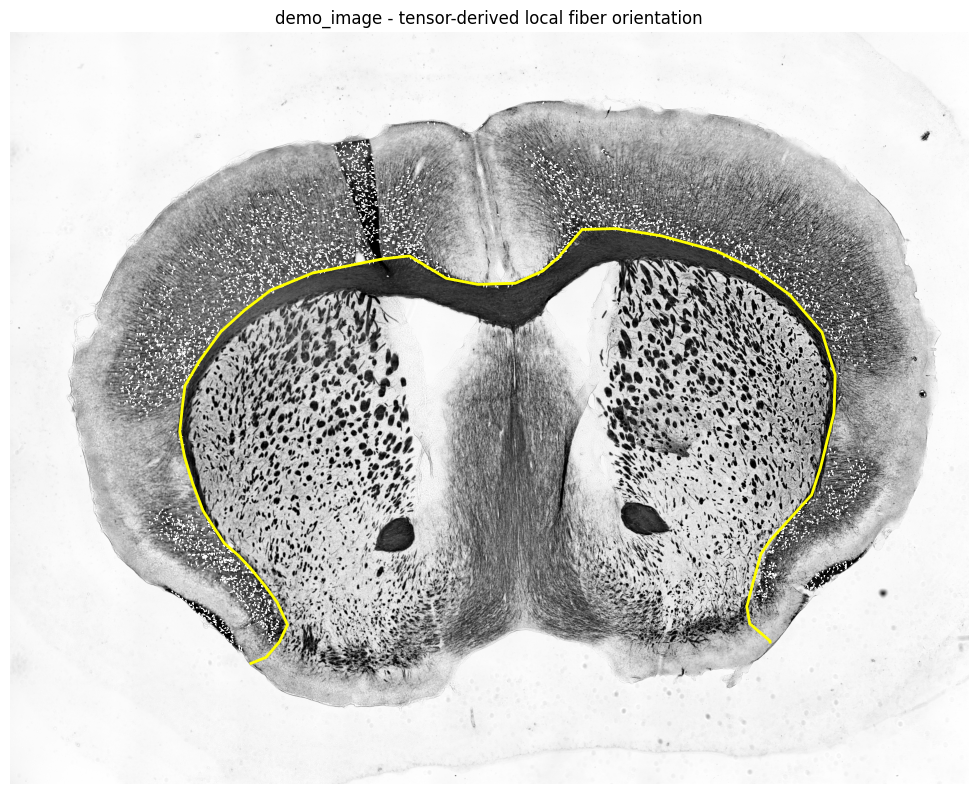

Saved tensor orientation image: /Users/lauraducret/blackgold-myelin-pipeline/outputs/1_cortical_fibers/figures/tensor_orientation_overlays/demo_image_tensor_orientation_overlay.png


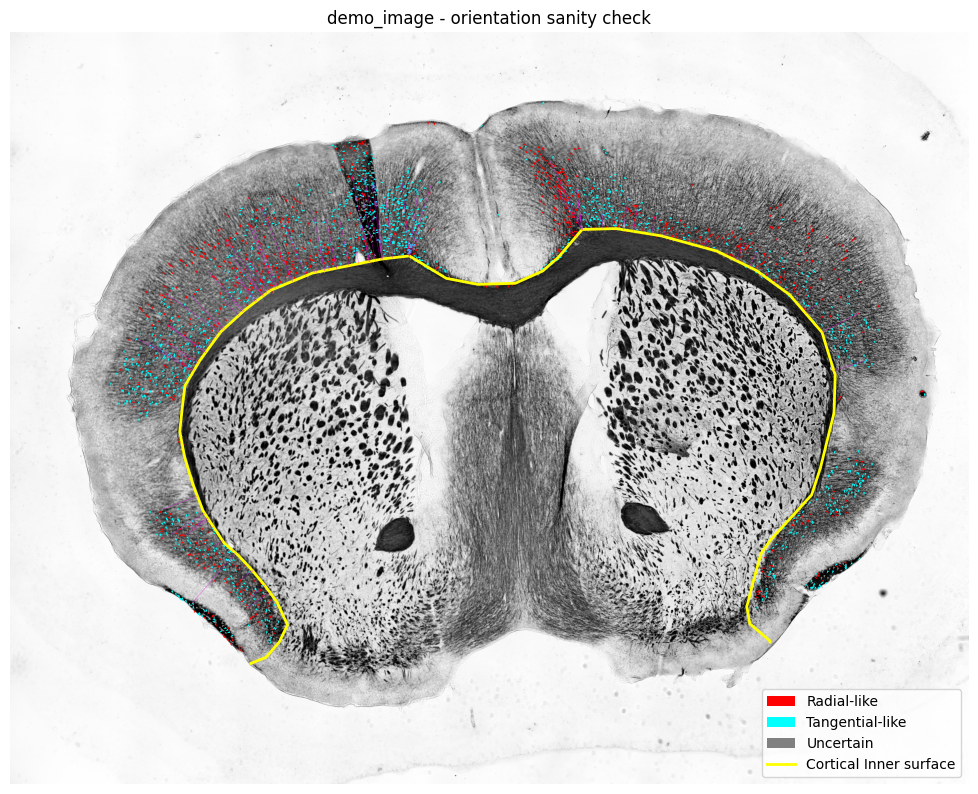

Saved: /Users/lauraducret/blackgold-myelin-pipeline/outputs/1_cortical_fibers/figures/orientation_overlays/demo_image_orientation_overlay.png
Radial: 1007 Tangential: 1254


,sample_id,sigma,coherence_threshold,angle_threshold,intensity_threshold,cortex_area_px,mean_cortex_intensity_raw,median_cortex_intensity_raw,std_cortex_intensity_raw,total_classified,radial,tangential,uncertain,total_vectors,radial_density,tangential_density,uncertain_density,radial_fraction,tangential_fraction
0,demo_image,1.0,0.5,25,0.6,10851653,36737.811004,37880.0,11075.080121,2261,1007,1254,1687,3948,0.000093,0.000116,0.000155,0.445378,0.554622


In [19]:
analysis_rows = []

sigma = 1.0
coherence_threshold = 0.5
angle_threshold = 25
myelin_percentile = 75
step = 500
vector_length = 25
threshold = 0.6

debug_overlay = True
display_original = True

ORIENTATION_FIGURES_DIR = FIGURES_DIR / "orientation_overlays"
ORIENTATION_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


for _, sample in samples.iterrows():

    sample_id = sample["sample_id"]
    print(f"\nProcessing {sample_id}")

    filtered_path = PREPROCESS_DIR / f"{sample_id}_directional_filtered.tif"
    image = io.imread(filtered_path)

    if image.ndim == 3:
        image = image.mean(axis=2)

    if display_original:
        original_path = sample["image_path"]
        raw_display_image = io.imread(original_path)

        if raw_display_image.ndim == 3:
            raw_display_image = raw_display_image.mean(axis=2)

        display_image = normalize01(raw_display_image)

    else:
        display_image = image

    rois = ImagejRoi.fromfile(sample["roi_zip_path"])
    cortex_roi = get_roi_by_name(rois, "cortex")
    inner_roi = get_roi_by_name(rois, "Inner")

    cortex_mask = roi_to_mask(cortex_roi, image.shape)
    cortex_area = cortex_mask.sum()

    cortex_intensity_values = raw_display_image[cortex_mask]

    mean_cortex_intensity = float(np.mean(cortex_intensity_values))
    median_cortex_intensity = float(np.median(cortex_intensity_values))
    std_cortex_intensity = float(np.std(cortex_intensity_values))

    myelin_signal = normalize01_within_mask(image, cortex_mask)

    Axx, Axy, Ayy = structure_tensor(image, sigma=sigma)
    eigvals = structure_tensor_eigenvalues((Axx, Axy, Ayy))

    l1 = eigvals[0]
    l2 = eigvals[1]

    fiber_angle = 0.5 * np.degrees(np.arctan2(2 * Axy, Axx - Ayy))

    # Rotate so vectors align with the visible fibers rather than perpendicular to them
    fiber_angle = fiber_angle + 90

    coherence = (l1 - l2) / (l1 + l2 + 1e-10)

    valid_mask = (
        cortex_mask
        & (myelin_signal > threshold)
        & (coherence > coherence_threshold)
    )

    yy, xx = np.where(valid_mask)

    yy = yy[::step]
    xx = xx[::step]

    fiber_angles = fiber_angle[yy, xx]

    surface_coords, tangent_angles = surface_tangent_angles(
        inner_roi,
        spacing=2
    )

    nearest_x, nearest_y, local_tangent, local_radial = nearest_surface_reference(
        pixel_y=yy,
        pixel_x=xx,
        surface_coords=surface_coords,
        tangent_angles=tangent_angles
    )

    relative_to_radial = angle_difference_deg(fiber_angles, local_radial)
    relative_to_tangential = angle_difference_deg(fiber_angles, local_tangent)

    radial = relative_to_radial < angle_threshold
    tangential = relative_to_tangential < angle_threshold

    uncertain = ~(radial | tangential)

    theta = np.radians(fiber_angles)
    u = vector_length * np.cos(theta)
    v = vector_length * np.sin(theta)

    TENSOR_FIGURES_DIR = FIGURES_DIR / "tensor_orientation_overlays"
    TENSOR_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(display_image, cmap="gray")

    plt.quiver(
        xx, yy,
        u, v,
        color="white",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003
    )

    plt.plot(
        surface_coords[:, 0],
        surface_coords[:, 1],
        color="yellow",
        linewidth=2
    )

    plt.title(f"{sample_id} - tensor-derived local fiber orientation")
    plt.axis("off")
    plt.tight_layout()

    tensor_out = TENSOR_FIGURES_DIR / f"{sample_id}_tensor_orientation_overlay.png"
    plt.savefig(tensor_out, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()

    print(f"Saved tensor orientation image: {tensor_out}")

    plt.figure(figsize=(10, 8))
    plt.imshow(display_image, cmap="gray")

    plt.quiver(
        xx[radial], yy[radial],
        u[radial], v[radial],
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003,
        label="Radial-like"
    )

    plt.quiver(
        xx[tangential], yy[tangential],
        u[tangential], v[tangential],
        color="cyan",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003,
        label="Tangential-like"
    )
    plt.quiver(
        xx[uncertain], yy[uncertain],
        u[uncertain], v[uncertain],
        color="grey",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003,
        label="Uncertain"
    )

    plt.plot(
        surface_coords[:, 0],
        surface_coords[:, 1],
        color="yellow",
        linewidth=2,
        label="Cortical Inner surface"
    )

    plt.title(f"{sample_id} - orientation sanity check")
    plt.legend(loc="lower right")
    plt.axis("off")
    plt.tight_layout()
    debug_idx = np.random.choice(
        np.arange(len(xx)),
        size=min(80, len(xx)),
        replace=False
    )

    if debug_overlay:
        for i in debug_idx:
            plt.plot(
                [xx[i], nearest_x[i]],
                [yy[i], nearest_y[i]],
                color="magenta",
                linewidth=0.5,
                alpha=0.4
            )

    out = ORIENTATION_FIGURES_DIR / f"{sample_id}_orientation_overlay.png"
    plt.savefig(out, dpi=300)

    plt.show()

    print(f"Saved: {out}")
    print("Radial:", radial.sum(), "Tangential:", tangential.sum())

    radial_density = radial.sum() / cortex_area
    tangential_density = tangential.sum() / cortex_area
    uncertain_density = uncertain.sum() / cortex_area

    radial_fraction = radial.sum() / (radial.sum() + tangential.sum())
    tangential_fraction = tangential.sum() / (radial.sum() + tangential.sum())

    analysis_rows.append({
        "sample_id": sample_id,
        "sigma": sigma,
        "coherence_threshold": coherence_threshold,
        "angle_threshold": angle_threshold,
        "intensity_threshold": threshold,

        "cortex_area_px": int(cortex_area),
        "mean_cortex_intensity_raw": mean_cortex_intensity,
        "median_cortex_intensity_raw": median_cortex_intensity,
        "std_cortex_intensity_raw": std_cortex_intensity,

        "total_classified": int(radial.sum() + tangential.sum()),
        "radial": int(radial.sum()),
        "tangential": int(tangential.sum()),
        "uncertain": int(uncertain.sum()),
        "total_vectors": int(len(xx)),
        "radial_density":radial_density,
        "tangential_density":tangential_density,
        "uncertain_density":uncertain_density,
        "radial_fraction":radial_fraction,
        "tangential_fraction":tangential_fraction
    })

analysis_df = pd.DataFrame(analysis_rows)

analysis_out = TABLES_DIR / "analysis_table_thresholds.csv"
analysis_df.to_csv(analysis_out, index=False)

analysis_df

# 4. Analysis
Preliminary plots.

In [20]:
df = pd.read_csv(TABLES_DIR / "analysis_table_thresholds.csv")

df["TR_ratio"] = df["tangential_density"] / df["radial_density"]

print(df[["sample_id", "radial_fraction", "tangential_fraction", "TR_ratio"]])

    sample_id  radial_fraction  tangential_fraction  TR_ratio
0  demo_image         0.445378             0.554622  1.245283


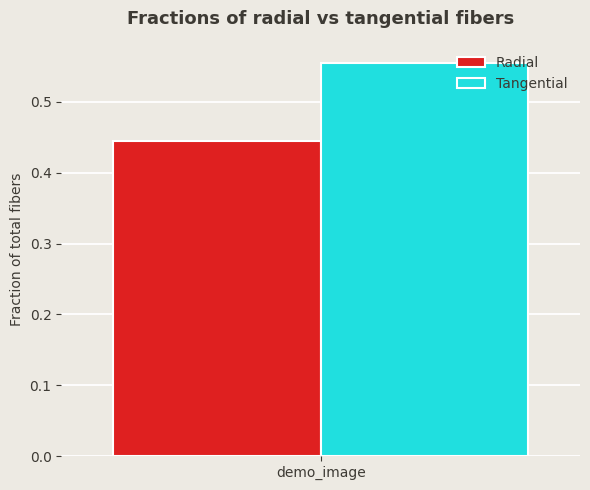

In [21]:
FIBER_COLORS = {
    "Radial": "red",      
    "Tangential": "cyan"
}

BG_COLOR = "#EDEAE3"
TEXT_COLOR = "#3d3a34"

plot_df = df.melt(
    id_vars=["sample_id"],
    value_vars=["radial_fraction", "tangential_fraction"],
    var_name="fiber_type",
    value_name="fraction",
)
plot_df["fiber_type"] = plot_df["fiber_type"].map({
    "radial_fraction": "Radial",
    "tangential_fraction": "Tangential"
})


fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

sns.barplot(
    data=plot_df,
    x="sample_id",
    y="fraction",
    hue="fiber_type",
    hue_order=["Radial", "Tangential"],
    palette=FIBER_COLORS,
    edgecolor="white",
    linewidth=1.5,
    ax=ax,
)

ax.set_axisbelow(True)
ax.grid(axis="y", color="white", linewidth=1.3)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylabel("Fraction of total fibers", color=TEXT_COLOR)
ax.set_xlabel("")
ax.set_title(
    "Fractions of radial vs tangential fibers",
    color=TEXT_COLOR, fontsize=13, weight="bold", pad=14,
)
ax.tick_params(colors=TEXT_COLOR)

legend = ax.legend(frameon=False, title=None, loc="upper right")
for text in legend.get_texts():
    text.set_color(TEXT_COLOR)

plt.tight_layout()
plt.show()